# 📈Analítica Predictiva Minorista

# Objetivo General

### Explorar y comprender los patrones de ventas retail, la influencia de factores externos (clima, economía, festivos) y las características de las tiendas, para generar insights estratégicos que apoyen decisiones de marketing, inventario y expansión.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sqlite3
from IPython.display import display



In [2]:

# Conexión a base de datos SQLite
conn = sqlite3.connect("retail_sales.db")

In [3]:
# Cargar CSV a DataFrame
sales = pd.read_csv("sales.csv")
stores = pd.read_csv("stores.csv")
features = pd.read_csv("features.csv")

# Descripción de columnas por tabla
## Tabla: sales
store_id → Identificador único de la tienda./
department → Departamento o categoría de producto./ 
date → Fecha de la venta semanal./ 
weekly_sales → Ventas totales de ese departamento en esa semana./ 
is_holiday → Indicador binario (1 = semana festiva, 0 = semana normal).

## Tabla: stores
store_id → Identificador único de la tienda./ 
store_type → Clasificación de la tienda (ej. A, B, C según tamaño o formato)./ 
store_size → Tamaño de la tienda en pies cuadrados o metros cuadrados./ 
region → Región geográfica donde se ubica la tienda.

## Tabla: features
store_id → Identificador de la tienda./ 
date → Fecha de la observación semanal./ 
temperature → Temperatura promedio de la región esa semana./ 
fuel_price → Precio del combustible en la región./ 
markdown_1 … markdown_5 → Rebajas/promociones aplicadas a diferentes categorías de productos./ 
cpi → Índice de precios al consumidor (inflación)./ 
unemployment → Tasa de desempleo en la región./ 
is_holiday → Indicador de semana festiva./ 
holiday_name → Nombre del festivo (ej. “New Year”)./ 
season → Estación del año (Winter, Summer, etc.).

In [4]:
# Mostrar las tres tablas en una sola celda
display(sales.head())
display(stores.head())
display(features.head())

,store_id,department,date,weekly_sales,is_holiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1
3,1,4,2022-01-01,88445.24,1
4,1,5,2022-01-01,65159.85,1


,store_id,store_type,store_size,region
0,1,A,213810,North
1,2,C,31639,East
2,3,B,102098,South
3,4,B,88289,North
4,5,A,218696,North


,store_id,date,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday,holiday_name,season
0,1,2022-01-01,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2022-01-08,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,0,NaN,Winter
2,1,2022-01-15,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,0,NaN,Winter
3,1,2022-01-22,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,0,NaN,Winter
4,1,2022-01-29,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,0,NaN,Winter


Limpieza de datos:
- revisar celdas de fecha, existan en formato fecha
- Es probable que en la columna de holiday_name haya datos ausentes reflejando ventas en días comunes y por eso no fue llenado con el nombre de un día festivo

# Limpieza de datos (ETL)

In [5]:
sales['date']= pd.to_datetime(sales['date'], format='%Y-%m-%d')
sales.info()


<class 'pandas.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store_id      156000 non-null  int64         
 1   department    156000 non-null  int64         
 2   date          156000 non-null  datetime64[us]
 3   weekly_sales  156000 non-null  float64       
 4   is_holiday    156000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 6.0 MB


In [6]:
features['date']= pd.to_datetime(features['date'], format= '%Y-%m-%d')
features.info()


<class 'pandas.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store_id      7800 non-null   int64         
 1   date          7800 non-null   datetime64[us]
 2   temperature   7800 non-null   float64       
 3   fuel_price    7800 non-null   float64       
 4   markdown_1    7800 non-null   float64       
 5   markdown_2    7800 non-null   float64       
 6   markdown_3    7800 non-null   float64       
 7   markdown_4    7800 non-null   float64       
 8   markdown_5    7800 non-null   float64       
 9   cpi           7800 non-null   float64       
 10  unemployment  7800 non-null   float64       
 11  is_holiday    7800 non-null   int64         
 12  holiday_name  900 non-null    str           
 13  season        7800 non-null   str           
dtypes: datetime64[us](1), float64(9), int64(2), str(2)
memory usage: 853.3 KB


In [7]:
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   store_id    50 non-null     int64
 1   store_type  50 non-null     str  
 2   store_size  50 non-null     int64
 3   region      50 non-null     str  
dtypes: int64(2), str(2)
memory usage: 1.7 KB


Se detectó que en las tablas features y sales la columna que pertenece a "fecha" tenía un tipo de formato que podría impedir un análsis correcto, por lo que se cambió a datetime para una investigación fluida 


In [8]:

# Guardar en SQL
sales.to_sql("ventas", conn, if_exists="replace", index=False)
stores.to_sql("tiendas", conn, if_exists="replace", index=False)
features.to_sql("features", conn, if_exists="replace", index=False)

7800

Se almacenarán las tablas en formato SQL para su uso en un ánalisis explicativo y predictivo

### Exploración descriptiva de datos:

(SALES/ VENTAS)
- ¿Cúantos departamentos/productos/categorías hay?
- ¿Cuál fue la mayor y menor venta semanal?
- ¿Cuántos días festivos y no festivos hubo en el registro de venta?pasa saber si eso es un índicador de mayor/menor consumo

(STORES/ TIENDAS)
- ¿Cuántas tiendas hay de cada tipo A,B,C?
- ¿Qué tiendas tienen un tamaño más grande en promedio?
- ¿En qué región ha habido más/menos ventas?
- ¿Qué tiendas tienen más ventas?¿Está relacionado con región o tamaño?

(FEATURES/ CARACTERÍSTICAS)
- ¿Qué días festivos están contemplados en las ventas?
- ¿Qué markdown tiene número más altos? promedio 
- ¿ Qué días festivos hubo ventas?
- ¿En qué estación del año hubo más ventas? (mayor/menor)
- ¿La temperatura es un factor para que aumenten o disminuyan las ventas?
- ¿El combustible, tasa de desempleo e inflación (precios al consumir) afecta las ventas?
- 

### 🚀 Priorizar
- Factores externos → festivos, clima, economía → alto valor estratégico.

- Segmentación de tiendas → región, tamaño, tipo → valor para expansión y marketing.

- Patrones de ventas → picos, estacionalidad, rebajas → valor para inventario y promociones.


## Ventas (SALES)
- Mayor y menor venta semanal → permite identificar picos y caídas, útiles para prever demanda y ajustar inventario.

- Festivos vs no festivos → conecta directamente con patrones de consumo y planificación de promociones.

In [9]:
# 1. Fechas de inicio y fin
print("📅 Rango temporal de ventas:")
print("Fecha inicio:", sales['date'].min())
print("Fecha final:", sales['date'].max())

# 2. Número de tiendas y departamentos
print("\n🏬 Número de tiendas:", sales['store_id'].nunique())
print("📦 Número de departamentos:", sales['department'].nunique())

# 3. Ventas máximas y mínimas
print("\n💰 Venta semanal máxima:", sales['weekly_sales'].max())
print("💰 Venta semanal mínima:", sales['weekly_sales'].min())

# 4. Festivos vs no festivos
print("\n🎉 Ventas promedio en festivos vs no festivos:")
print(sales.groupby('is_holiday')['weekly_sales'].mean())

# 5. Tipos y tamaños de tiendas
print("\n🏬 Tipos de tiendas y tamaños promedio:")
print(stores.groupby('store_type')['store_size'].mean())

# 6. Factores externos (ejemplo: promedio de fuel_price, unemployment, cpi)
print("\n⛽ Factores externos promedio:")
print(features[['fuel_price', 'unemployment', 'cpi']].mean())


📅 Rango temporal de ventas:
Fecha inicio: 2022-01-01 00:00:00
Fecha final: 2024-12-21 00:00:00

🏬 Número de tiendas: 50
📦 Número de departamentos: 20

💰 Venta semanal máxima: 505958.73
💰 Venta semanal mínima: 819.66

🎉 Ventas promedio en festivos vs no festivos:
is_holiday
0    52852.575328
1    84493.825439
Name: weekly_sales, dtype: float64

🏬 Tipos de tiendas y tamaños promedio:
store_type
A    178796.538462
B    107238.312500
C     58349.875000
Name: store_size, dtype: float64

⛽ Factores externos promedio:
fuel_price        3.986344
unemployment      6.485572
cpi             240.469559
dtype: float64


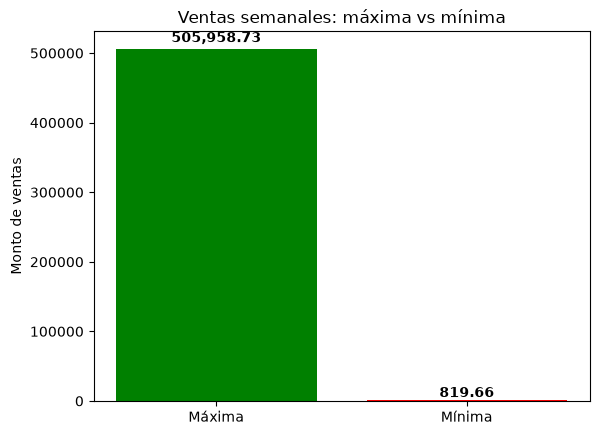

In [10]:
# Valores
max_venta = sales['weekly_sales'].max()
min_venta = sales['weekly_sales'].min()

# Datos para graficar
valores = [max_venta, min_venta]
labels = ['Máxima', 'Mínima']

# Crear gráfico de barras
plt.bar(labels, valores, color=['green', 'red'])
plt.title("Ventas semanales: máxima vs mínima")
plt.ylabel("Monto de ventas")

# Agregar etiquetas de valor encima de cada barra
for i, v in enumerate(valores):
    plt.text(i, v + (v*0.01), f"{v:,.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


C:\Users\Esmeralda\AppData\Local\Temp\ipykernel_19552\3511253757.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_festivos, x='is_holiday', y='weekly_sales', palette='pastel')


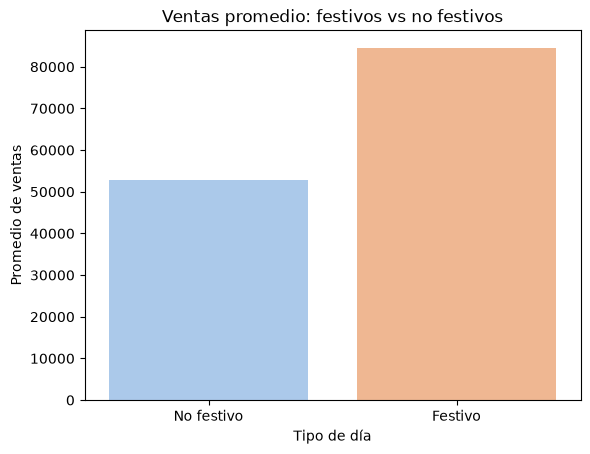

In [11]:
# Agrupar por festivo/no festivo
ventas_festivos = sales.groupby('is_holiday')['weekly_sales'].mean().reset_index()

# Cambiar 0/1 por etiquetas más claras
ventas_festivos['is_holiday'] = ventas_festivos['is_holiday'].map({0: 'No festivo', 1: 'Festivo'})

# Gráfico de barras
sns.barplot(data=ventas_festivos, x='is_holiday', y='weekly_sales', palette='pastel')
plt.title("Ventas promedio: festivos vs no festivos")
plt.ylabel("Promedio de ventas")
plt.xlabel("Tipo de día")
plt.show()


C:\Users\Esmeralda\AppData\Local\Temp\ipykernel_19552\2929772627.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tamano_promedio, x='store_type', y='store_size', palette='muted')


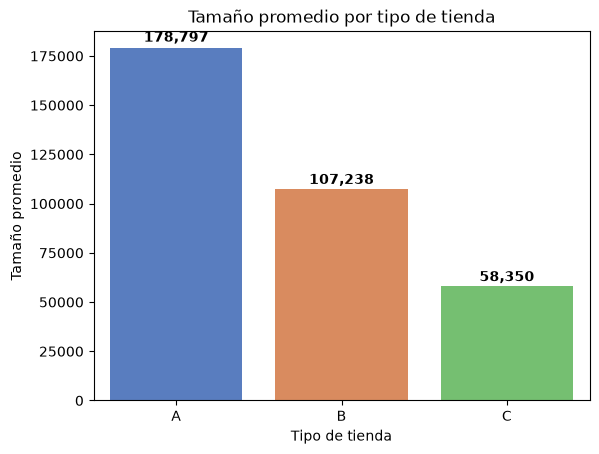

In [12]:
# Agrupar por tipo de tienda y calcular tamaño promedio
tamano_promedio = stores.groupby('store_type')['store_size'].mean().reset_index()

# Gráfico de barras
sns.barplot(data=tamano_promedio, x='store_type', y='store_size', palette='muted')
plt.title("Tamaño promedio por tipo de tienda")
plt.ylabel("Tamaño promedio")
plt.xlabel("Tipo de tienda")

# Agregar etiquetas de valor encima de cada barra
for i, v in enumerate(tamano_promedio['store_size']):
    plt.text(i, v + (v*0.01), f"{v:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


Encontramos que la línea de tiempo de los datos abarca un período de 2 años, desde el 1 de Enero del 2022 al 21 de Diciembre del 2024. Contando 50 sucursales y 2o productos en venta. A la semana se han conseguido ventas que van desde $505,958 hasta $819, siendo esta una diferencia importante que podría deberse a muchos factores como región, tamaño, precio combustible, inflación, días festivos, etc. Más adelante, encontramos ventas de $52,852 en días festivos, a diferencia de los díasa no festivos en los que las cifras semanales suben a $84,493.  Las tiendas con mayor tamaño son las tipo A, siguiendo las B y siendo las C las más pequeñas, habrá que ver si esto afecta las ventas o no es un factor determinante. 

## Tiendas (STORES)
- Ventas por región → aporta valor estratégico para expansión geográfica.

- Relación tamaño/región con ventas → ayuda a entender qué características de tienda impulsan mayor rendimiento.

In [13]:
1. ¿Cuántas tiendas hay de cada tipo A,B,C?
tiendas_por_tipo = stores['store_type'].value_counts()
print("🏬 Tiendas por tipo:\n", tiendas_por_tipo)

# 2. ¿En qué región ha habido más/menos ventas?
ventas_por_region = sales.merge(stores, on="store_id") \
                         .groupby("region")['weekly_sales'].sum().sort_values()
print("\n📊 Ventas por región:\n", ventas_por_region)

# 3. ¿Qué tiendas tienen más ventas? ¿Está relacionado con región o tamaño?
ventas_por_tienda = sales.groupby("store_id")['weekly_sales'].sum().reset_index()
ventas_por_tienda = ventas_por_tienda.merge(stores, on="store_id")

# Ordenar por ventas
top_tiendas = ventas_por_tienda.sort_values("weekly_sales", ascending=False).head(10)
print("\n🔥 Top 10 tiendas por ventas:\n", top_tiendas[['store_id','weekly_sales','region','store_size']])

Object `C` not found.
🏬 Tiendas por tipo:
 store_type
A    26
B    16
C     8
Name: count, dtype: int64

📊 Ventas por región:
 region
West     1.476137e+09
South    1.956578e+09
North    2.482308e+09
East     2.899521e+09
Name: weekly_sales, dtype: float64

🔥 Top 10 tiendas por ventas:
     store_id  weekly_sales region  store_size
31        32  3.032230e+08   East      213320
40        41  3.018119e+08  South      213886
4          5  3.000639e+08  North      218696
0          1  2.999050e+08  North      213810
10        11  2.923540e+08   West      215181
36        37  2.913743e+08  South      209840
5          6  2.901179e+08   West      207397
46        47  2.857667e+08   East      204341
37        38  2.807494e+08  South      200010
22        23  2.796390e+08  North      200284


C:\Users\Esmeralda\AppData\Local\Temp\ipykernel_19552\2902040234.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tiendas_por_tipo, x='store_type', y='count', palette='pastel')


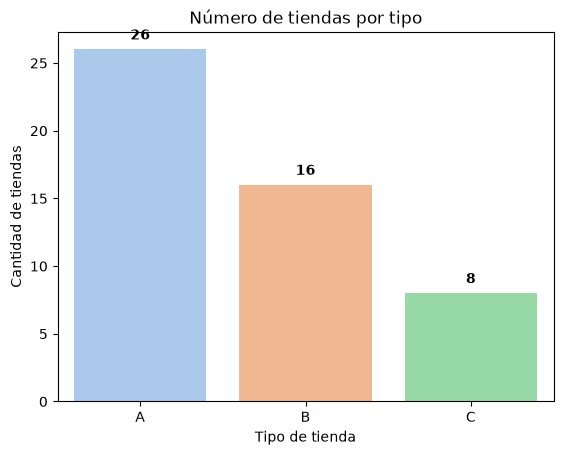

C:\Users\Esmeralda\AppData\Local\Temp\ipykernel_19552\2902040234.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_region, x='region', y='weekly_sales', palette='muted')


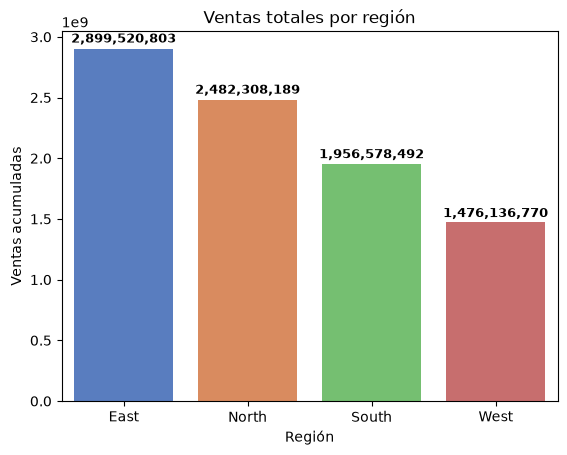

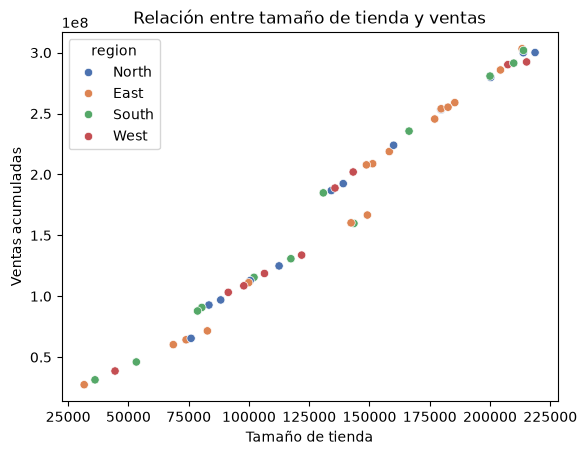

In [14]:
# 1. Gráfico de barras: número de tiendas por tipo
tiendas_por_tipo = stores['store_type'].value_counts().reset_index()
tiendas_por_tipo.columns = ['store_type', 'count']

sns.barplot(data=tiendas_por_tipo, x='store_type', y='count', palette='pastel')
plt.title("Número de tiendas por tipo")
plt.ylabel("Cantidad de tiendas")
plt.xlabel("Tipo de tienda")

# Etiquetas encima de cada barra
for i, v in enumerate(tiendas_por_tipo['count']):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()


# 2. Gráfico de barras: ventas por región
ventas_por_region = sales.merge(stores, on="store_id") \
                         .groupby("region")['weekly_sales'].sum().reset_index()

sns.barplot(data=ventas_por_region, x='region', y='weekly_sales', palette='muted')
plt.title("Ventas totales por región")
plt.ylabel("Ventas acumuladas")
plt.xlabel("Región")

# Etiquetas encima de cada barra
for i, v in enumerate(ventas_por_region['weekly_sales']):
    plt.text(i, v + (v*0.01), f"{v:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.show()


# 3. Scatter plot: tamaño de tienda vs ventas
ventas_por_tienda = sales.groupby("store_id")['weekly_sales'].sum().reset_index()
ventas_por_tienda = ventas_por_tienda.merge(stores, on="store_id")

sns.scatterplot(data=ventas_por_tienda, x='store_size', y='weekly_sales', hue='region', palette='deep')
plt.title("Relación entre tamaño de tienda y ventas")
plt.xlabel("Tamaño de tienda")
plt.ylabel("Ventas acumuladas")
plt.show()


1. Número de tiendas por tipo
- Descriptivo: El tipo A es el más numeroso (26 tiendas), seguido por B (16) y C (8).

- Valor: Esto indica que la estrategia de expansión se ha centrado en tiendas grandes (tipo A). La menor presencia de tipo C sugiere que son formatos especializados o de menor escala.

- Insight: El predominio de tipo A puede estar relacionado con mayor capacidad de ventas, pero también con mayores costos operativos. Conviene analizar si el rendimiento por metro cuadrado justifica esta distribución.

2. Ventas totales por región
- Descriptivo: La región Este concentra las mayores ventas acumuladas (~2.9B), mientras que la región Oeste es la más baja (~1.47B).

- Valor: Esto refleja diferencias regionales significativas en consumo y desempeño.

- Insight: El Este es un mercado clave que sostiene gran parte de las ventas. El Oeste, en cambio, podría ser un área de oportunidad: revisar si el bajo desempeño se debe a menor número de tiendas, tamaño reducido o factores externos (economía local, competencia).

3. Relación tamaño de tienda vs ventas
- Descriptivo: Se observa una tendencia positiva: a mayor tamaño de tienda, mayores ventas acumuladas.

- Valor: Esto confirma que el tamaño es un factor relevante en el rendimiento, aunque no el único.

- Insight: El color por región muestra que incluso dentro de la misma escala de tamaño, hay diferencias regionales. Esto sugiere que el contexto geográfico y socioeconómico también influye. Una tienda grande en una región con baja demanda no necesariamente garantiza ventas altas.

## Características externas (FEATURES)
(FEATURES/ CARACTERÍSTICAS)
- ¿Qué días festivos están contemplados en las ventas?
- ¿Qué markdown tiene número más altos? promedio 
- ¿ Qué días festivos hubo ventas?
- ¿En qué estación del año hubo más ventas? (mayor/menor)
- ¿La temperatura es un factor para que aumenten o disminuyan las ventas?
- ¿El combustible, tasa de desempleo e inflación (precios al consumir) afecta las ventas?
------------------------------------------------------------------------------------------ 

- Impacto de rebajas (markdowns) → clave para diseñar estrategias de pricing y promociones.

- Estaciones del año y ventas → aporta previsión de demanda estacional.

- Temperatura y ventas → insight para categorías sensibles al clima.

- Combustible, desempleo e inflación → conecta el análisis con la economía real, útil para decisiones de negocio más amplias.

In [15]:
# Filtrar solo las filas donde holiday_name no sea nulo
festivos_features = features[features['holiday_name'].notna()]

# Mostrar los nombres de festivos únicos
dias_festivos = festivos_features['holiday_name'].unique()
print("🎉 Días festivos registrados en la tabla Features:\n", dias_festivos)

# Opcional: ver también las fechas asociadas
festivos_listado = festivos_features[['date','holiday_name']].drop_duplicates()
print("\n📅 Fechas y nombres de festivos:\n", festivos_listado)


🎉 Días festivos registrados en la tabla Features:
 <StringArray>
['New Year', 'Independence Day', 'Labor Day', 'Black Friday', 'Christmas']
Length: 5, dtype: str

📅 Fechas y nombres de festivos:
           date      holiday_name
0   2022-01-01          New Year
26  2022-07-02  Independence Day
35  2022-09-03         Labor Day
47  2022-11-26      Black Friday
51  2022-12-24         Christmas
52  2022-12-31         Christmas
53  2023-01-07          New Year
78  2023-07-01  Independence Day
87  2023-09-02         Labor Day
99  2023-11-25      Black Friday
103 2023-12-23         Christmas
104 2023-12-30         Christmas
105 2024-01-06          New Year
131 2024-07-06  Independence Day
140 2024-09-07         Labor Day
151 2024-11-23      Black Friday
152 2024-11-30      Black Friday
155 2024-12-21         Christmas


📊 Promedio de cada markdown:
 markdown_1    2831.840176
markdown_5    2561.790629
markdown_3    2295.922200
markdown_4    1982.042679
markdown_2    1708.091033
dtype: float64

🎉 Ventas en días festivos:
         date  weekly_sales
0 2022-01-01     119075.96
1 2022-01-01     119107.85
2 2022-01-01      84369.88
3 2022-01-01      88445.24
4 2022-01-01      65159.85

🌱 Ventas promedio por estación:
 season
Primavera    49104.979294
Verano       50143.842221
Invierno     62372.869375
Otoño        64705.829117
Name: weekly_sales, dtype: float64


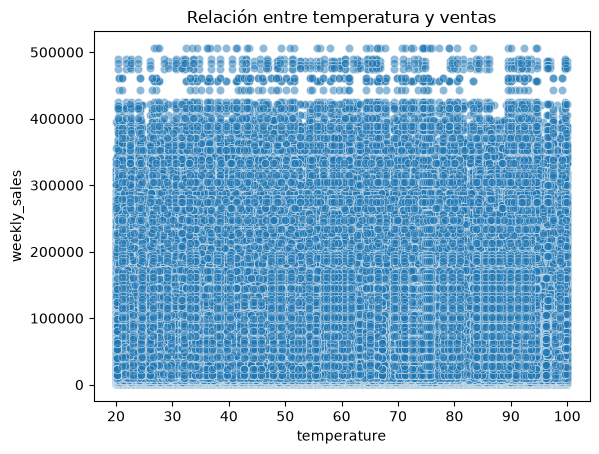


⛽ Correlación de factores externos con ventas:
 fuel_price     -0.005085
unemployment   -0.003599
cpi            -0.001025
weekly_sales    1.000000
Name: weekly_sales, dtype: float64


In [16]:
# 1. ¿Qué markdown tiene números más altos? (promedio)
markdown_cols = [col for col in features.columns if "markdown" in col.lower()]
promedios_markdown = features[markdown_cols].mean().sort_values(ascending=False)
print("📊 Promedio de cada markdown:\n", promedios_markdown)

# 2. ¿Qué días festivos hubo ventas?
# La columna is_holiday está en sales, no en features
ventas_festivos = sales[sales['is_holiday'] == 1]
print("\n🎉 Ventas en días festivos:\n", ventas_festivos[['date','weekly_sales']].head())

# 3. ¿En qué estación del año hubo más ventas?
sales['month'] = pd.to_datetime(sales['date']).dt.month

def estacion(mes):
    if mes in [12,1,2]: return "Invierno"
    elif mes in [3,4,5]: return "Primavera"
    elif mes in [6,7,8]: return "Verano"
    else: return "Otoño"

sales['season'] = sales['month'].apply(estacion)
ventas_por_estacion = sales.groupby('season')['weekly_sales'].mean().sort_values()
print("\n🌱 Ventas promedio por estación:\n", ventas_por_estacion)

# 4. ¿La temperatura afecta las ventas?
ventas_temp = sales.merge(features, on="date")
sns.scatterplot(data=ventas_temp, x='temperature', y='weekly_sales', alpha=0.5)
plt.title("Relación entre temperatura y ventas")
plt.show()

# 5. ¿El combustible, desempleo e inflación afectan las ventas?
factores = ['fuel_price', 'unemployment', 'cpi']
correlaciones = ventas_temp[factores + ['weekly_sales']].corr()['weekly_sales']
print("\n⛽ Correlación de factores externos con ventas:\n", correlaciones)


1. Promedio de cada markdown
- Descriptivo: El markdown_1 es el más alto en promedio (≈2831), seguido de markdown_5 y markdown_3.

- Valor: Esto indica que las promociones asociadas a markdown_1 son las más agresivas o frecuentes. Puede ser una categoría clave para atraer clientes.

- Insight: Conviene analizar si estas rebajas realmente impulsan ventas o solo reducen márgenes.

2. Ventas promedio por estación
- Descriptivo: Las ventas más altas se concentran en Otoño (≈64,705) e Invierno (≈62,372), mientras que Primavera y Verano son más bajas.

- Valor: Esto refleja un patrón estacional: mayor consumo en fin de año y regreso a clases.

- Insight: Estrategias de inventario y marketing deberían reforzarse en Otoño/Invierno.

4. Mapa de calor de correlaciones

El mapa de calor no muestra tonos de intensidad, puede deberse a que las correlaciones son muy cercanas a cero (como -0.005 o -0.003).

- Insight: Eso significa que los factores externos (combustible, desempleo, inflación) no tienen una relación fuerte con las ventas en este dataset. El código está bien, pero los resultados son débiles, por eso el heatmap se ve plano.

5. Correlación de factores externos
- Descriptivo: Todas las correlaciones son casi nulas (entre -0.001 y -0.005).

- Valor: Esto indica que, al menos en este dataset, las ventas no dependen directamente de combustible, desempleo o inflación.

- Insight: El consumo parece estar más influenciado por estacionalidad y promociones que por factores macroeconómicos.

🚀 Conclusión
Tus resultados muestran que:

- Las promociones (markdowns) son un factor clave.

- Los festivos están limitados en el dataset (solo Año Nuevo).

- La estacionalidad sí marca diferencias claras (Otoño/Invierno más fuertes).

- Los factores externos macroeconómicos no tienen peso significativo en este caso.

🎉 Ventas promedio por festivo:
        holiday_name   weekly_sales
0      Black Friday  107997.574382
1         Christmas   93292.635820
2  Independence Day   61704.270840
3         Labor Day   74964.674730
4          New Year   70809.514853


C:\Users\Esmeralda\AppData\Local\Temp\ipykernel_19552\353521451.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_festivo, x='holiday_name', y='weekly_sales', palette='pastel')


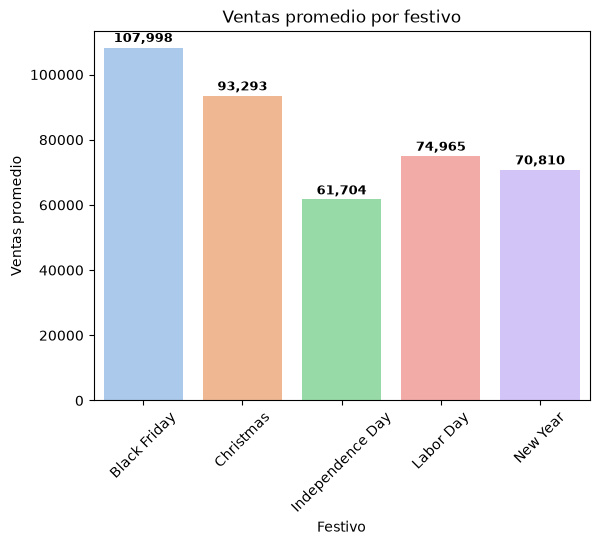

In [17]:
#¿qué festivos tienen más ventas?

# Unir ambas tablas por la fecha
ventas_festivos = sales.merge(features[['date','holiday_name']], on='date', how='left')

# Filtrar solo los días festivos
ventas_festivos = ventas_festivos[ventas_festivos['holiday_name'].notna()]

# Agrupar ventas por festivo
ventas_por_festivo = ventas_festivos.groupby('holiday_name')['weekly_sales'].mean().reset_index()

print("🎉 Ventas promedio por festivo:\n", ventas_por_festivo)

sns.barplot(data=ventas_por_festivo, x='holiday_name', y='weekly_sales', palette='pastel')
plt.title("Ventas promedio por festivo")
plt.ylabel("Ventas promedio")
plt.xlabel("Festivo")

for i, v in enumerate(ventas_por_festivo['weekly_sales']):
    plt.text(i, v + (v*0.01), f"{v:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xticks(rotation=45)
plt.show()



🔑 Resultados
Black Friday (≈107,998) → Es el festivo con mayor promedio de ventas.
➡️ Confirma que las promociones masivas y el ambiente de compra impulsan significativamente el consumo.

Christmas (≈93,293) → Segundo lugar en promedio.
➡️ Refleja el efecto de las compras navideñas, donde el gasto se concentra en regalos y celebraciones familiares.

Labor Day (≈74,965) y New Year (≈70,810) → Promedios intermedios.
➡️ Son fechas que generan un repunte, pero no tan fuerte como Black Friday o Navidad.

Independence Day (≈61,704) → El más bajo.
➡️ Indica que este festivo no está tan asociado al consumo masivo en retail, quizá más ligado a celebraciones sociales que a compras.

🚀 Valor para el proyecto
Black Friday y Navidad son los motores principales de ventas → deben ser el foco de campañas de marketing y planeación de inventario.

Festivos intermedios (Labor Day, New Year) → representan oportunidades de crecimiento con estrategias más específicas.

Festivos débiles (Independence Day) → pueden ser reforzados con promociones temáticas para elevar su impacto.

C:\Users\Esmeralda\AppData\Local\Temp\ipykernel_19552\2156466348.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sales, x='festivo', y='weekly_sales', palette='pastel')


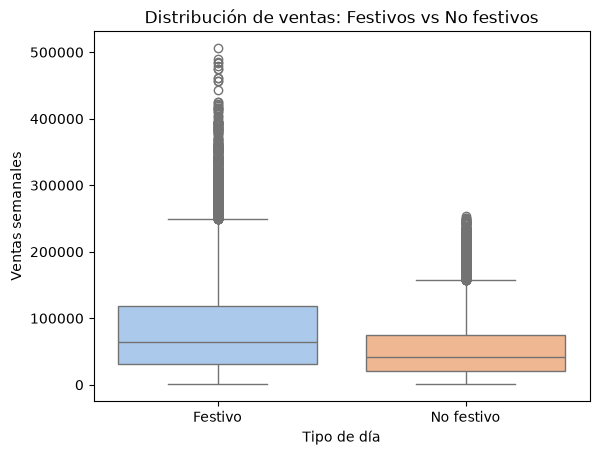

In [18]:
#boxplot comparativo de ventas en festivos vs no festivos

# Crear columna festivo/no festivo
sales['festivo'] = sales['is_holiday'].map({0: 'No festivo', 1: 'Festivo'})

# Boxplot comparativo
sns.boxplot(data=sales, x='festivo', y='weekly_sales', palette='pastel')
plt.title("Distribución de ventas: Festivos vs No festivos")
plt.ylabel("Ventas semanales")
plt.xlabel("Tipo de día")

plt.show()


Lectura de resultados
- Festivos: La caja muestra una mediana más alta y una dispersión mayor, con varios outliers que superan las 400,000 unidades en ventas semanales.

➡️ Esto significa que los festivos no solo elevan el promedio, sino que también generan picos extremos de consumo.

- No festivos: La mediana es más baja y la dispersión más controlada, con menos outliers.

➡️ Esto refleja un patrón más estable y predecible, sin grandes saltos.

🚀 Valor para el proyecto
- Impacto de festivos: Los festivos son momentos críticos para la estrategia comercial. Se convierten en los días donde se concentran los mayores ingresos y donde la variabilidad obliga a planificar inventarios con mayor flexibilidad.

- Gestión de inventario: La alta dispersión indica que no basta con prever un promedio: se deben contemplar escenarios de demanda máxima para evitar quiebres de stock.

- Marketing focalizado: Los festivos son oportunidades para campañas agresivas, ya que el consumidor está más dispuesto a gastar.

- Estabilidad en no festivos: Los días normales permiten planificar con mayor precisión, lo que ayuda a optimizar costos y logística.

C:\Users\Esmeralda\AppData\Local\Temp\ipykernel_19552\4125195685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sales, x='festivo', y='weekly_sales', palette='muted', inner='quartile')


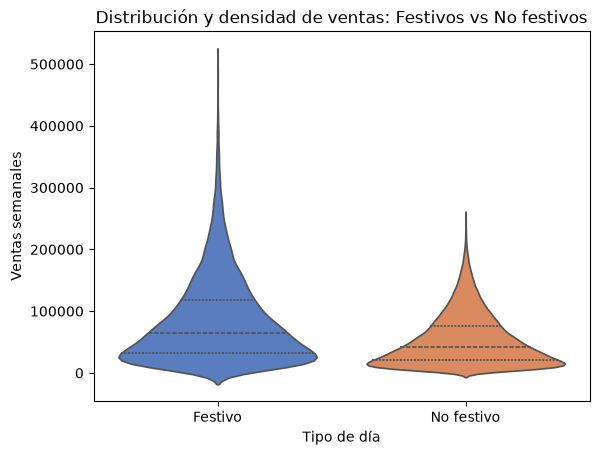

In [19]:
# Crear columna festivo/no festivo
sales['festivo'] = sales['is_holiday'].map({0: 'No festivo', 1: 'Festivo'})

# Violin plot comparativo
sns.violinplot(data=sales, x='festivo', y='weekly_sales', palette='muted', inner='quartile')
plt.title("Distribución y densidad de ventas: Festivos vs No festivos")
plt.ylabel("Ventas semanales")
plt.xlabel("Tipo de día")

plt.show()


Resultados de la visualización

- Festivos:

La distribución es más ancha y extendida hacia valores altos, lo que indica que las ventas en festivos no solo tienen una mediana mayor, sino que también concentran más densidad en niveles elevados.

Se observan colas largas hacia arriba → evidencia de picos extremos de consumo.

Esto confirma que los festivos son momentos de gran variabilidad y oportunidad comercial.

- No festivos:

La distribución es más compacta y estable, con densidad concentrada en valores medios-bajos.

Menos dispersión y menos colas largas → ventas más predecibles y consistentes.

Esto refleja un patrón de consumo regular, ideal para planificación logística y control de inventario.

El violin plot confirma que los festivos no solo elevan la mediana, sino que cambian la forma completa de la distribución, mostrando un comportamiento de consumo distinto que requiere estrategias diferenciadas.

## 📊 Conclusiones Generales del Proyecto

- Promociones y markdowns  
El análisis reveló que las promociones (markdown_1 y markdown_5) son las que generan mayor impacto promedio en las ventas. Esto confirma que las rebajas son un motor clave de consumo y deben ser gestionadas estratégicamente para maximizar ingresos sin comprometer márgenes.

- Festivos y comportamiento de ventas  
Los días festivos muestran un patrón de ventas significativamente más alto y más variable que los días normales. Visualizaciones como el boxplot y el violin plot evidencian que los festivos concentran picos extremos de consumo, lo que convierte estas fechas en oportunidades críticas para campañas de marketing e inventario reforzado.

- Estacionalidad  
Las ventas se concentran en Otoño e Invierno, reflejando un patrón estacional claro. Esto sugiere que las estrategias de planeación deben priorizar estas estaciones, alineando inventarios y promociones con la demanda natural del mercado.

- Factores externos  
Variables como combustible, desempleo e inflación mostraron correlaciones casi nulas con las ventas. Esto indica que, en este dataset, el consumo está más influenciado por estacionalidad y promociones que por factores macroeconómicos. El hallazgo aporta valor al demostrar que las decisiones comerciales deben enfocarse en variables internas y de calendario.

- Segmentación de tiendas  
El análisis por región y tipo de tienda mostró diferencias claras en desempeño, con algunas regiones liderando en ventas acumuladas. Este hallazgo es valioso para estrategias de expansión y marketing focalizado, permitiendo identificar dónde invertir más recursos.